# 0. Imports

In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df = pd.read_csv(
    './data/Demanda_2015.txt',
    sep='\t',
    header=None,
    names=['date', 'hour', 'demand']
 )



df['date'] = pd.to_datetime(
    df['date'] + ' ' + df['hour'],
    format='%d/%m/%y %H:%M'
)
df.drop(columns=['hour'], inplace=True)

df['hour'] = df.date.dt.hour
df['minute'] = df.date.dt.minute
df['day'] = df.date.dt.day
df['month'] = df.date.dt.month
df['week'] = df.date.dt.isocalendar().week
df['weekday'] = df.date.dt.weekday
df['quarter'] = df.date.dt.quarter


# df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%y')
# df['hora'] = df['hora'].str.split(':').str[0] + ':' + df['hora'].str.split(':').str[1]

# df = df.set_index('fecha_hora').drop(columns=['fecha', 'hora'])
df.head()

,date,demand,hour,minute,day,month,week,weekday,quarter
0,2015-01-01 00:00:00,25459,0,0,1,1,1,3,1
1,2015-01-01 00:10:00,25591,0,10,1,1,1,3,1
2,2015-01-01 00:20:00,25531,0,20,1,1,1,3,1
3,2015-01-01 00:30:00,25453,0,30,1,1,1,3,1
4,2015-01-01 00:40:00,25329,0,40,1,1,1,3,1


In [9]:
df.shape

(52560, 1)

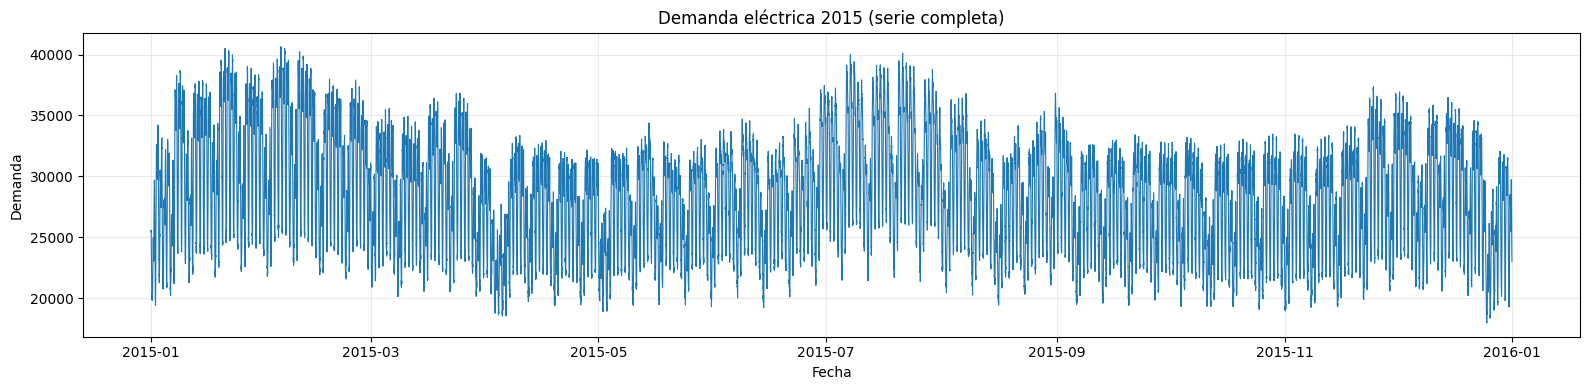

Rango temporal: 2015-01-01 00:00:00 -> 2015-12-31 23:50:00
Número de registros: 52560
Valores nulos en demanda: 0


In [17]:
# Paso 1: vista global de la serie
df_plot = df.copy()
df_plot['demanda'] = pd.to_numeric(df_plot['demanda'], errors='coerce')
df_plot = df_plot.sort_values('fecha_hora').set_index('fecha_hora')

plt.figure(figsize=(16, 4))
plt.plot(df_plot.index, df_plot['demanda'], linewidth=0.8)
plt.title('Demanda eléctrica 2015 (serie completa)')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Rango temporal:', df_plot.index.min(), '->', df_plot.index.max())
print('Número de registros:', len(df_plot))
print('Valores nulos en demanda:', df_plot['demanda'].isna().sum())